Para abrir o notebook no Google Colab, altere o domínio `github.com` para `githubtocolab.com`

<div class="alert alert-block alert-danger">
Para praticar programação, é importante que você erre, leia as mensagens de erro e tente corrigí-los.
    
Dessa forma, no Google Colab, é importante que você DESATIVE OS RECURSOS DE AUTOCOMPLETAR:

- Menu Ferramentas -> Configurações
- Na janela que é aberta:
  - Seção Editor -> Desativar "Mostrar sugestões de preenchimento de código com base no contexto"
  - Seção Assistência de IA -> Desabilitar itens

Na versão em inglês:

- Menu Tools -> Settings
- Na janela que é aberta:
  - Seção Editor -> Desativar "Show context-powered code completions"
  - Seção AI Assistance -> Desabilitar itens
</div>

# Exercício 2: Neurônio de Rosenblatt

Um dos experimentos feitos com o perceptron de Rosenblatt consistia na classificação de caracteres. Um caractere era exposto na frente de uma matriz de sensores, que digitalizava a imagem e os elementos dessa matriz eram utilizados como entradas do perceptron.

A ideia consistia em alimentar diversos perceptrons com essas entradas, que funcionariam em paralelo, de forma independente uns dos outros. Cada um era treinado para classificar um determinado caractere, fornecendo saída igual a 1 no caso da detecção do caractere em questão ou -1, no caso da detecção de qualquer outro caractere. Assim, era possível obter uma estrutura com várias saídas, cada uma representando o reconhecimento de um determinado caractere.

Rosenblatt teorizou vários tipos de perceptron aplicados a diferentes aplicações. Dentre estes, estão o *photoperceptron*, para tarefas visuais e o *phonoperceptron*, para tarefas de áudio. Neste exercício, você trabalhará em uma aplicação simplificada do phonoperceptron: um classificador binário utilizando o perceptron de Rosenblatt para determinar se um áudio corresponde a alguém dizendo a palavra "sim" (*yes*) ou "não" (*no*).

Antes de iniciar, certifique-se de ter baixado o arquivo [`train.zip`](./train.zip) com os dados e deixá-lo no mesmo diretório do Jupyter Notebook.

In [78]:
!unzip train.zip -o -d content

Archive:  train.zip
caution: filename not matched:  -o


Inicialmente, vamos carregar os arquivos de áudio na matriz **X** e os rótulos correspondentes na uma matriz coluna **Y**.  Para isso pode ser utilizado o código a seguir:

In [79]:
# Standard Library
# =========================
import os

# =========================
# Visualization
# =========================
import matplotlib.pyplot as plt

# =========================
# Numerical Computing
# =========================
import numpy as np

# =========================
# Audio Processing
# =========================
from scipy.io import wavfile
from scipy.signal import spectrogram

X = []
Y = []
lengths = []
folder = "./content/train/"
files = os.listdir(folder)
for file in files:
    if file.endswith("wav"):
        filepath = os.path.join(folder, file)
        fs, x = wavfile.read(filepath)
        x = x[:30000]
        X.append(x)
        if file.startswith("yes"):
            Y.append(1)
        if file.startswith("no"):
            Y.append(-1)
        lengths.append(len(x))
X = np.array(X)
Y = np.array(Y)

Observe que há um truncamento no tamanho de `X`. Isso ocorre porque os áudios não possuem o mesmo comprimento. Para que os dados possam ser alimentados ao perceptron, é essencial que todos tenham o mesmo tamanho. Por esse motivo, decidiu-se truncar `X` considerando o menor comprimento dos áudios contidos no banco de dados.

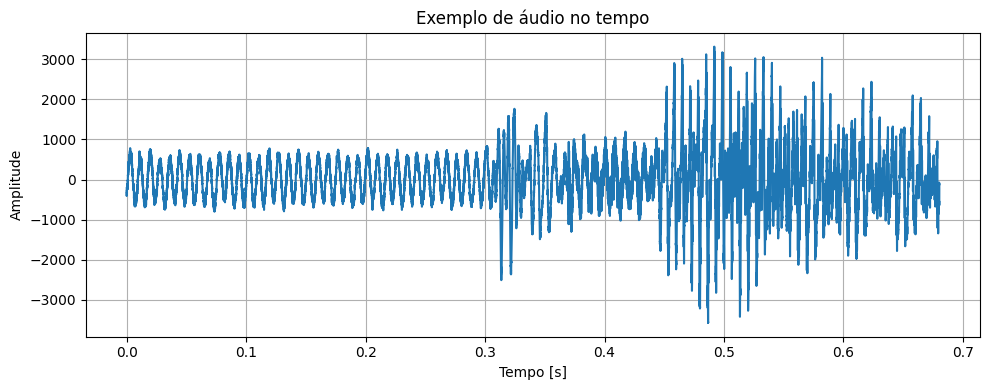

In [80]:
t_step = np.arange(len(X[0])) / fs
plt.figure(figsize=(10, 4))
plt.plot(t_step, X[0])
plt.xlabel("Tempo [s]")
plt.ylabel("Amplitude")
plt.title("Exemplo de áudio no tempo")
plt.grid(True)
plt.tight_layout()
plt.show()

In [81]:
# Ouvindo o sinal mostrado acima
import soundfile as sf
from IPython.display import Audio

Audio(X[0].T, rate=fs)

A matriz de dados possui 800 linhas e 30000 colunas. Cada linha corresponde a um exemplo do banco de dados. As 30000 colunas representam as amostras de um sinal de áudio discretizado no tempo, ou seja, cada coluna corresponde a uma amostra do sinal de áudio, com frequência de amostragem (fs) de 44100 Hz.

Embora seja possível alimentar a rede diretamente com todas as amostras do sinal de áudio no domínio do tempo (ou seja, utilizando as 30000 colunas como entrada), essa abordagem implica um custo computacional elevado e, em muitos casos, desnecessário. Isso ocorre porque o sinal bruto contém redundâncias e informações irrelevantes para a tarefa de classificação, o que aumenta a dimensionalidade do problema sem necessariamente melhorar o desempenho do modelo.

Para processar melhor o áudio, portanto, sugere-se algum tipo de transformação. Por exemplo, pode-se utilizar como entrada do perceptron o espectrograma de cada sinal. Para isso, utiliza-se uma função da biblioteca SciPy. Não se pode esquecer de concatenar os espectrogramas com os rótulos.



In [82]:
from scipy.signal import spectrogram

SX = []
Sxyes = []
Sxno = []
n_aud = X.shape[0]
for n in range(n_aud):
    x = X[n, :]
    f, t, Sxx = spectrogram(x, fs, nperseg=256, noverlap=128)
    Sxx = np.log1p(Sxx)
    SX.append(Sxx)
SX = np.array(SX)
SX = SX.reshape(SX.shape[0], -1)
print(f"Tamanho de Sx:{SX.shape}")
Xd = np.hstack((SX, Y.reshape(-1, 1)))

Tamanho de Sx:(800, 30057)


Podemos gerar um gráfico do espectrograma resultante:

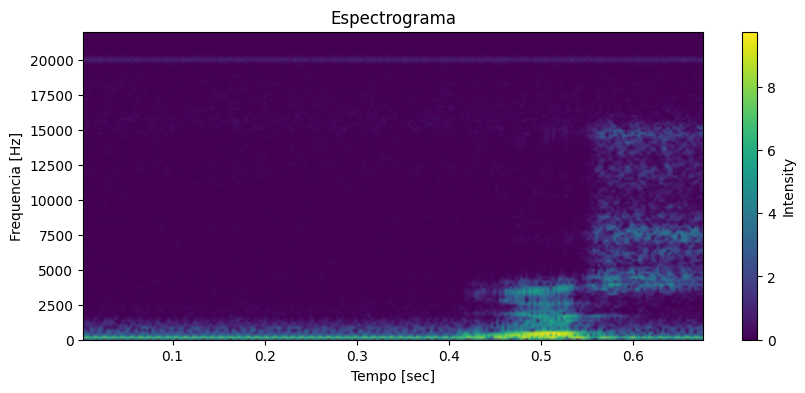

In [83]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.pcolormesh(t, f, Sxx, shading="gouraud")
plt.ylabel("Frequencia [Hz]")
plt.xlabel("Tempo [sec]")
plt.title("Espectrograma")
plt.colorbar(label="Intensity")
plt.show()

Como é possível observar na imagem, a energia do espectrograma concentra-se em uma faixa específica de frequências. A complexidade do perceptron está diretamente relacionada à dimensão do vetor de entrada, ou seja, ao tamanho do vetor de características para cada dado utilizado na entrada.

Por esse motivo, recomenda-se buscar formas de reduzir a dimensionalidade da entrada do modelo, seja utilizando apenas a região do espectrograma que contém informação significativa, seja aplicando outra transformação que permita uma representação mais compacta dos dados. Por exemplo, pode-se utilizar como entrada do perceptron os coeficientes MFCC *(Mel-Frequency Cepstral Coefficients*), utilizar banco de filtros, ou até mesmo utilizar PCA (*Principal Component Analysis*). [Como inspiração, veja algumas transformações nesse artigo](https://arxiv.org/abs/2112.05555).

A atribuição da nota deste exercício levará em consideração tanto o desempenho do modelo quanto o seu custo computacional. É importante deixar claro no vídeo a transformação considerada e o número de pesos do perceptron.

Realizamos a sepração dos dados em treino (70% dos dados) e teste (30% dos dados).

In [84]:
Xd_train = Xd[:560, :]
Xd_teste = Xd[560:, :]

O rótulo referente à imagem pode ser obtido com o elemento da última coluna:

In [85]:
y_train = Xd_train[:, -1]
y_teste = Xd_teste[:, -1]
print(y_train.shape)
print(y_teste.shape)

(560,)
(240,)


Como você pode observar, o rótulo igual a 1 é usado para identificar a palavra *yes* e o rótulo igual a -1 é usado para identificar a palavra  *no*.

Você deve implementar uma função para treinar o perceptron de Rosenblatt de forma iterativa, dados a matriz `Xd`, um passo de adaptação `eta`, o número de épocas `Ne` e o tamanho do *mini-batch* `Nb`. Após o treinamento, avalie o seu modelo com os dados dos conjuntos de treinamento e de teste, medindo a acurácia do classificador para ambos os casos. A escolha desses hiperparâmetros fica a critério do aluno, devendo-se buscar uma configuração que proporcione um bom desempenho no conjunto de dados de teste.

Além disso, deve-se também implementar um modelo de classificação baseado em regressão logística, comparando a acurácia obtida no conjunto de teste entre os dois modelos. **Observação importante: Utilize somente a biblioteca NumPy para a implementação do perceptron e da regressão logística.**


A acurácia ou taxa de acerto é definida como o número de predições corretas realizadas pelo modelo dividido pelo número total de predições. Ou seja, a acurária é o complementar da taxa de erro.

**Observação: Essa medida deve ser calculada com os dados de teste para verificar a qualidade do modelo.**




Ao final do exercício, você deverá apresentar:

1. Os códigos utilizados para treinar o modelo e avaliá-lo com os conjuntos de treinamento e de teste;

2. O valor obtido para a acurácia considerando os dados de teste tanto para o perceptron de Rosenblatt quanto para a regressão logística.

A sugestão é que o relatório seja elaborado utilizando um Jupyter Notebook e a linguagem Python, já que essas são as ferramentas que estamos utilizando nesta parte do curso. No entanto, isso não é obrigatório e você pode usar outra linguagem de programação, caso queira.

## Instruções para entrega

- O exercício pode ser feito em dupla ou individualmente;

- A entrega deve incluir:
  - Um vídeo de no **máximo 40s**, mostrando a resolução do exercício;
  - Os **códigos-fontes** dos programas, preferencialmente organizados em um Jupyter Notebook, descrevendo o experimento e mostrando como foram obtidos os resultados solicitados.

- **A correção será feita baseada no vídeo**. Quando o professor/pesquisador ficar com alguma dúvida, serão consultados os códigos-fonte;

- Sobre o vídeo:
  - **Deve incluir áudio** descrevendo o experimento;
  - Gravem a tela do computador usando celular ou usando algum programa de captura de tela (por exemplo Zoom, Google Meet, ou OBS Studio);
  - No início, **deve aparecer o rosto e algum documento do aluno que gravou o vídeo** (como a carteira USP, RG, CNH, etc);
  - No caso de entrega em dupla, **não é necessário que os dois componentes apareçam no vídeo**. No entanto, alternem o apresentador ao longo das entregas dos exercícios e **não esqueçam de incluir os dois nomes no início do vídeo**.
  - Procurem convencer o espectador do vídeo, que vai corrigir o exercício que fizeram os exercícios computacionais solicitados e que eles estão funcionando corretamente. Tentem fazer um bom aproveitamento do tempo para apresentar os resultados solicitados, **respeitando o limite de 40s e não acelerem a velocidade do vídeo**;

- Sobre os códigos-fonte:
  - **Incluir o nome do(s) aluno(s)** no início do programa;

- Sobre o envio no Moodle:
  - Apenas um aluno de cada dupla deve enviar o vídeo no Moodle;
  - Podem ser enviados o arquivo de vídeo (.mkv, .mp4, .avi, etc.) ou um link para o vídeo (Youtube, Google Drive, etc);
    - No segundo caso, certifiquem-se que todos os professores/pesquisadores (magno.silva@usp.br, hae.kim@usp.br, sergiocaceres01@usp.br, renatocan@lps.usp.br) tenham acesso ao seu vídeo.
  - Não se esqueçam de escrever o nome dos componentes da dupla (ou do único aluno, escrevendo: "exercício feito individualmente") em três lugares diferentes: **no campo "comentários sobre o envio" no Moodle**, **no início do vídeo** e no **início dos códigos-fonte**.



# Identificação
**Aluno:** Gabriel Cordeiro Caram
=
## 1. Separação dos Dados e Redução de Dimensionalidade (PCA)
Para diminuir o custo computacional e o número de pesos no Perceptron, vamos aplicar o PCA (Análise de Componentes Principais) utilizando apenas a biblioteca NumPy. Reduziremos a imensa quantidade de atributos do espectrograma achatado para um número muito menor de componentes principais.

In [86]:
X_train_raw = Xd_train[:, :-1]

y_train = Xd_train[:, -1]



X_teste_raw = Xd_teste[:, :-1]

y_teste = Xd_teste[:, -1]

In [87]:
# centralizar os dados de treino
X_mean = np.mean(X_train_raw, axis=0)
X_train_centered = X_train_raw - X_mean

In [88]:
# calcular a matriz de covariância das amostras para evitar erro de memória (utilizar covariância geral estava causando sobrecarga de memória)
N = X_train_centered.shape[0]
gram_matrix = np.dot(X_train_centered, X_train_centered.T) / (N - 1)

In [89]:
# obter autovalores e autovetores da matriz reduzida
eigenvalues, eigenvectors_N = np.linalg.eigh(gram_matrix)

In [90]:
# ordenar em ordem decrescente de importância
sorted_index = np.argsort(eigenvalues)[::-1]
eigenvectors_N = eigenvectors_N[:, sorted_index]

In [91]:
# converter os autovetores para o espaço de características original
k_componentes = 50
U_k = eigenvectors_N[:, :k_componentes]
W_pca = np.dot(X_train_centered.T, U_k)
W_pca = W_pca / np.linalg.norm(W_pca, axis=0)

In [92]:
# aplicar a transformação nos dados de treino e teste
X_train_pca = np.dot(X_train_centered, W_pca)

X_teste_centered = X_teste_raw - X_mean
X_teste_pca = np.dot(X_teste_centered, W_pca)

print(f"dimensão original: {X_train_raw.shape[1]}")
print(f"nova dimensão: {X_train_pca.shape[1]}")

dimensão original: 30057
nova dimensão: 50


## 2. Implementação dos Modelos
Abaixo estão as classes para o Perceptron de Rosenblatt e para a Regressão Logística, com treinamento iterativo por mini-batch.

In [93]:
# modelo do perceptron de rosenblatt
class PerceptronRosenblatt:
    def __init__(self, eta=0.01, epochs=100, batch_size=32):
        self.eta = eta
        self.epochs = epochs
        self.batch_size = batch_size
        self.w = None

    def fit(self, X, y):
        # inicializa os pesos com zeros
        self.w = np.zeros(X.shape[1] + 1)
        n_samples = X.shape[0]

        for epoch in range(self.epochs):
            # embaralhar os dados
            indices = np.arange(n_samples)
            np.random.shuffle(indices)
            X_shuffled = X[indices]
            y_shuffled = y[indices]

            for i in range(0, n_samples, self.batch_size):
                X_batch = X_shuffled[i:i+self.batch_size]
                y_batch = y_shuffled[i:i+self.batch_size]

                # adicionar bias
                X_batch_bias = np.c_[np.ones(X_batch.shape[0]), X_batch]

                # predição linear e atualização
                linear_output = np.dot(X_batch_bias, self.w)
                y_pred = np.where(linear_output >= 0, 1, -1)

                erros = y_batch - y_pred
                atualizacao = self.eta * np.dot(erros, X_batch_bias) / X_batch.shape[0]
                self.w += atualizacao

    def predict(self, X):
        X_bias = np.c_[np.ones(X.shape[0]), X]
        linear_output = np.dot(X_bias, self.w)
        return np.where(linear_output >= 0, 1, -1)

In [94]:
# modelo de regressão logística
class RegressaoLogistica:
    def __init__(self, eta=0.01, epochs=100, batch_size=32):
        self.eta = eta
        self.epochs = epochs
        self.batch_size = batch_size
        self.w = None

    def sigmoid(self, z):
        # limitar valores para evitar overflow
        z = np.clip(z, -250, 250)
        return 1.0 / (1.0 + np.exp(-z))

    def fit(self, X, y):
        # converter classes para zero e um
        y_bin = np.where(y == 1, 1, 0)
        self.w = np.zeros(X.shape[1] + 1)
        n_samples = X.shape[0]

        for epoch in range(self.epochs):
            indices = np.arange(n_samples)
            np.random.shuffle(indices)
            X_shuffled = X[indices]
            y_shuffled = y_bin[indices]

            for i in range(0, n_samples, self.batch_size):
                X_batch = X_shuffled[i:i+self.batch_size]
                y_batch = y_shuffled[i:i+self.batch_size]

                X_batch_bias = np.c_[np.ones(X_batch.shape[0]), X_batch]

                linear_output = np.dot(X_batch_bias, self.w)
                y_pred = self.sigmoid(linear_output)

                # gradiente descendente
                gradiente = np.dot(X_batch_bias.T, (y_pred - y_batch)) / X_batch.shape[0]
                self.w -= self.eta * gradiente

    def predict(self, X):
        X_bias = np.c_[np.ones(X.shape[0]), X]
        linear_output = np.dot(X_bias, self.w)
        y_pred_bin = self.sigmoid(linear_output) >= 0.5
        return np.where(y_pred_bin, 1, -1)

## 3. Treinamento e Avaliação
Vamos definir os hiperparâmetros (passo de adaptação `eta`, épocas `Ne` e `Nb` mini-batch), treinar os modelos e comparar os resultados.

In [95]:
# função auxiliar para acurácia
def calcular_acuracia(y_true, y_pred):
    return np.sum(y_true == y_pred) / len(y_true)

In [96]:
# parâmetros de treinamento
eta = 0.05
Ne = 200
Nb = 32

In [97]:
# treinar e avaliar perceptron
perceptron = PerceptronRosenblatt(eta=eta, epochs=Ne, batch_size=Nb)
perceptron.fit(X_train_pca, y_train)

y_pred_teste_perc = perceptron.predict(X_teste_pca)
acc_teste_perc = calcular_acuracia(y_teste, y_pred_teste_perc)

print(f"acurácia perceptron: {acc_teste_perc*100:.2f}%")
print(f"número de pesos: {len(perceptron.w)}")

acurácia perceptron: 99.58%
número de pesos: 51


In [98]:
# treinar e avaliar regressão logística
reg_log = RegressaoLogistica(eta=eta, epochs=Ne, batch_size=Nb)
reg_log.fit(X_train_pca, y_train)

y_pred_teste_rl = reg_log.predict(X_teste_pca)
acc_teste_rl = calcular_acuracia(y_teste, y_pred_teste_rl)

print(f"acurácia regressão logística: {acc_teste_rl*100:.2f}%")

acurácia regressão logística: 99.58%


## 4. Preparar gráficos para o vídeo
Organizar ilsutrações para facilitar entendimento do vídeo.

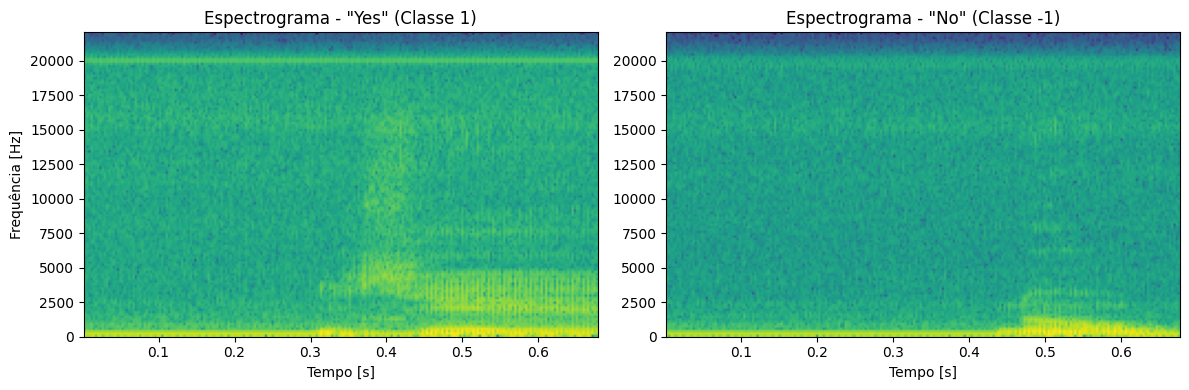

In [99]:
# os dados originais
# encontrar o primeiro áudio 'yes' e o primeiro 'no'
idx_yes = np.where(Y == 1)[0][0]
idx_no = np.where(Y == -1)[0][0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# plotando o espectrograma do 'yes'
Pxx1, freqs1, bins1, im1 = ax1.specgram(X[idx_yes], Fs=fs, NFFT=256, noverlap=128, cmap='viridis')
ax1.set_title('Espectrograma - "Yes" (Classe 1)')
ax1.set_ylabel('Frequência [Hz]')
ax1.set_xlabel('Tempo [s]')

# plotando o espectrograma do 'no'
Pxx2, freqs2, bins2, im2 = ax2.specgram(X[idx_no], Fs=fs, NFFT=256, noverlap=128, cmap='viridis')
ax2.set_title('Espectrograma - "No" (Classe -1)')
ax2.set_xlabel('Tempo [s]')

plt.tight_layout()
plt.show()

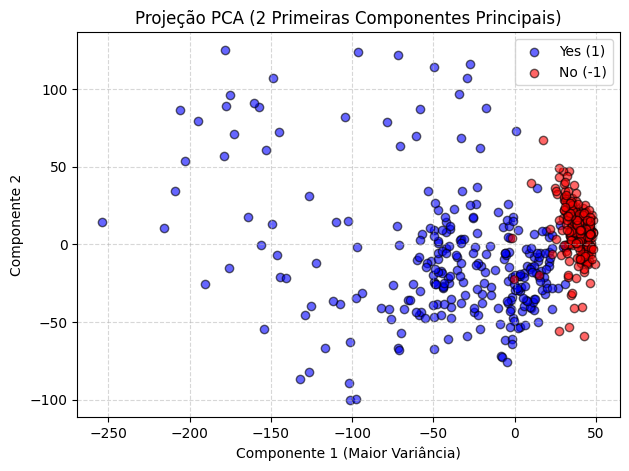

In [100]:
# etapa 2: o efeito do pca
# plotando apenas as duas primeiras componentes principais para ver se as classes se separam
plt.figure(figsize=(7, 5))

# separando os pontos por classe para colorir
pca_yes = X_train_pca[y_train == 1]
pca_no = X_train_pca[y_train == -1]

plt.scatter(pca_yes[:, 0], pca_yes[:, 1], color='blue', alpha=0.6, label='Yes (1)', edgecolors='k')
plt.scatter(pca_no[:, 0], pca_no[:, 1], color='red', alpha=0.6, label='No (-1)', edgecolors='k')

plt.title('Projeção PCA (2 Primeiras Componentes Principais)')
plt.xlabel('Componente 1 (Maior Variância)')
plt.ylabel('Componente 2')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

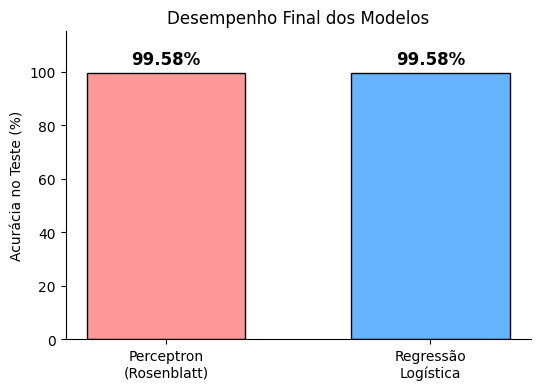

In [101]:
# comparativo final de acurácia
# um gráfico de barras
fig, ax = plt.subplots(figsize=(6, 4))

modelos = ['Perceptron\n(Rosenblatt)', 'Regressão\nLogística']
acuracias = [acc_teste_perc * 100, acc_teste_rl * 100]
cores = ['#ff9999', '#66b3ff']

barras = ax.bar(modelos, acuracias, color=cores, edgecolor='black', width=0.6)

# adicionando os valores no topo das barras
for barra in barras:
    altura = barra.get_height()
    ax.annotate(f'{altura:.2f}%',
                xy=(barra.get_x() + barra.get_width() / 2, altura),
                xytext=(0, 3),  # deslocamento vertical
                textcoords="offset points",
                ha='center', va='bottom', fontweight='bold', fontsize=12)

ax.set_ylim(0, 115) # espaço extra para o texto
ax.set_ylabel('Acurácia no Teste (%)')
ax.set_title('Desempenho Final dos Modelos')

# ocultando as bordas superior e direita
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()